<a href="https://colab.research.google.com/github/maimuna-noshin/Solar_Prediction/blob/main/Solar_Irradiance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solar Irradiance Prediction with Machine Learning

## Dataset

## Aim
To predict solar irradiance by ML model and find out adaptive MPPT for PV system

### Importing Required Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Importing The Dataset

In [ ]:
dataset = pd.read_csv('/content/train_solar.csv')

# Taking first 1000 rows
# dataset = dataset.head(10000)

dataset.head()

,Year,MonthOfYear,DayOfYear,TimeOfDay(Hour),TimeOfDay(Minute),Temperature,DewPoint,DiffuseHorizontalIrradiance(DHI),GlobalHorizontalIrradiance(GHI),SurfaceAlbedo,Pressure,WindDirection,WindSpeed,ClearskyDNI,CloudType,SolarZenithAngle,RelativeHumidity,Radiation(DNI)
0,2019,1,1,0,0,16.9,13.6,0,0,0.12,1016,333,1.0,0,3,179.26,81.11,0
1,2019,1,1,0,10,16.8,13.6,0,0,0.12,1016,336,1.0,0,3,177.94,81.63,0
2,2019,1,1,0,20,16.7,13.6,0,0,0.12,1016,339,1.0,0,4,175.70,82.15,0
3,2019,1,1,0,30,16.6,13.6,0,0,0.12,1016,343,1.0,0,7,173.43,82.67,0
4,2019,1,1,0,40,16.5,13.7,0,0,0.12,1016,346,1.0,0,4,171.14,83.49,0


### Exploratory Data Analysis (EDA)

In [ ]:
dataset.columns

Index(['Year', 'MonthOfYear', 'DayOfYear', 'TimeOfDay(Hour)',
       'TimeOfDay(Minute)', 'Temperature', 'DewPoint',
       'DiffuseHorizontalIrradiance(DHI)', 'GlobalHorizontalIrradiance(GHI)',
       'SurfaceAlbedo', 'Pressure', 'WindDirection', 'WindSpeed',
       'ClearskyDNI', 'CloudType', 'SolarZenithAngle', 'RelativeHumidity',
       'Radiation(DNI)'],
      dtype='object')

In [ ]:
dataset.shape

(210384, 18)

In [ ]:
dataset.describe()

,Year,MonthOfYear,DayOfYear,TimeOfDay(Hour),TimeOfDay(Minute),Temperature,DewPoint,DiffuseHorizontalIrradiance(DHI),GlobalHorizontalIrradiance(GHI),SurfaceAlbedo,Pressure,WindDirection,WindSpeed,ClearskyDNI,CloudType,SolarZenithAngle,RelativeHumidity,Radiation(DNI)
count,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000
mean,2017.498973,6.522930,15.729637,11.500000,25.000000,25.506576,21.254432,105.573741,202.512187,0.141458,1006.104067,200.815542,1.934351,240.463904,3.064672,89.760173,80.308194,149.751735
std,1.118342,3.448711,8.800113,6.922203,17.078292,5.240030,6.414540,141.895063,278.520039,0.008493,5.814652,85.190548,1.077844,292.431935,3.228813,43.524185,19.835382,224.865998
min,2016.000000,1.000000,1.000000,0.000000,0.000000,6.600000,-0.300000,0.000000,0.000000,0.120000,989.000000,0.000000,0.200000,0.000000,0.000000,0.310000,15.880000,0.000000
25%,2016.000000,4.000000,8.000000,5.750000,10.000000,22.700000,16.300000,0.000000,0.000000,0.140000,1001.000000,156.000000,1.100000,0.000000,0.000000,52.370000,68.950000,0.000000
50%,2017.000000,7.000000,16.000000,11.500000,25.000000,26.600000,23.700000,0.000000,0.000000,0.140000,1006.000000,185.000000,1.600000,0.000000,1.000000,89.390000,85.790000,0.000000
75%,2018.000000,10.000000,23.000000,17.250000,40.000000,29.000000,26.700000,202.000000,409.000000,0.150000,1011.000000,266.000000,2.500000,513.000000,7.000000,127.200000,97.780000,281.000000
max,2019.000000,12.000000,31.000000,23.000000,50.000000,40.800000,29.700000,514.000000,976.000000,0.160000,1020.000000,360.000000,8.000000,927.000000,9.000000,179.560000,100.000000,927.000000


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Data columns (total 18 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Year                              210384 non-null  int64  
 1   MonthOfYear                       210384 non-null  int64  
 2   DayOfYear                         210384 non-null  int64  
 3   TimeOfDay(Hour)                   210384 non-null  int64  
 4   TimeOfDay(Minute)                 210384 non-null  int64  
 5   Temperature                       210384 non-null  float64
 6   DewPoint                          210384 non-null  float64
 7   DiffuseHorizontalIrradiance(DHI)  210384 non-null  int64  
 8   GlobalHorizontalIrradiance(GHI)   210384 non-null  int64  
 9   SurfaceAlbedo                     210384 non-null  float64
 10  Pressure                          210384 non-null  int64  
 11  WindDirection                     210384 non-null  i

#### Is there any NULL values?

In [ ]:
dataset.isnull().sum()

,0
Year,0
MonthOfYear,0
DayOfYear,0
TimeOfDay(Hour),0
TimeOfDay(Minute),0
Temperature,0
DewPoint,0
DiffuseHorizontalIrradiance(DHI),0
GlobalHorizontalIrradiance(GHI),0
SurfaceAlbedo,0


#### Let's have a look at our target column

In [ ]:
dataset['Radiation(DNI)'].describe()

,Radiation(DNI)
count,210384.000000
mean,149.751735
std,224.865998
min,0.000000
25%,0.000000
50%,0.000000
75%,281.000000
max,927.000000


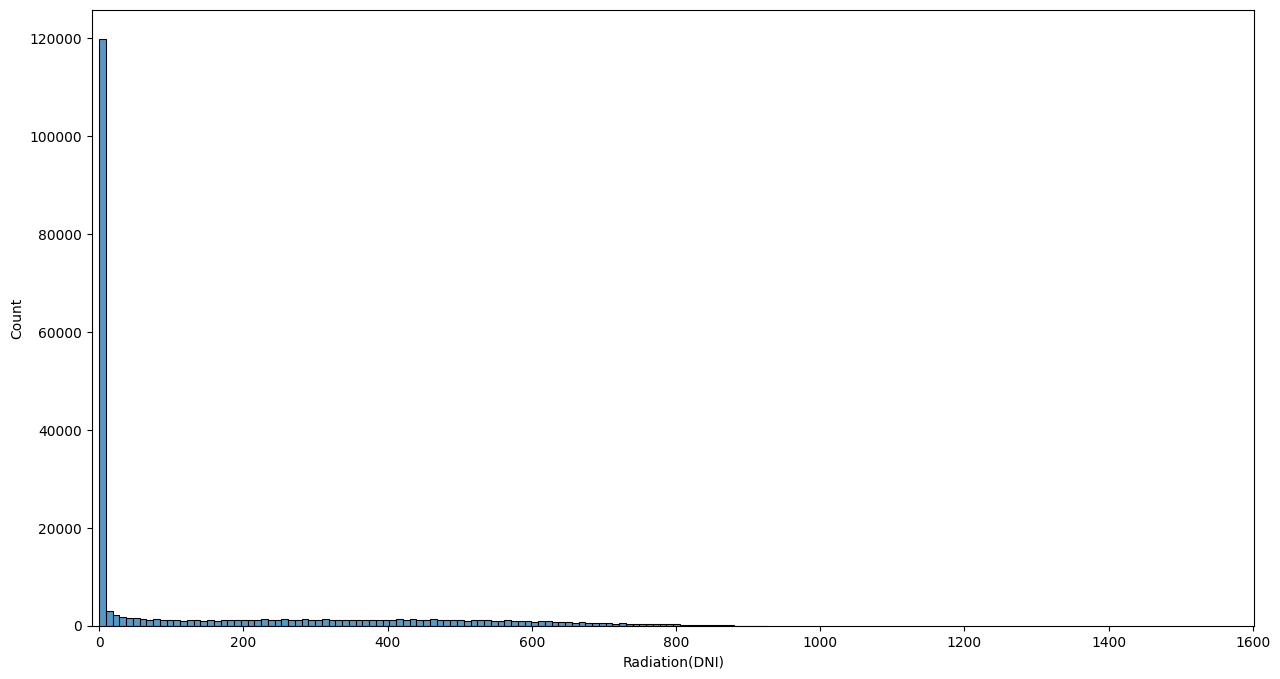

In [ ]:
# Create figure and axes
f, ax = plt.subplots(figsize=(15, 8))

sns.histplot(data=dataset['Radiation(DNI)'], ax=ax)
# sns.histplot(data=dataset['Radiation(DNI)'], ax=ax, kde=True)

# Set x-axis limits
plt.xlim([-10, 1602])

# Optional: Show the plot
plt.show()

### Feature Engineering

In [ ]:
# dataset['Pressure'] = dataset['Pressure'] / 1000
# dataset.head()
dataset = dataset.drop(['Year'], inplace=False, axis=1)

### Feature Visualization

Text(0.5, 1.0, 'WindSpeed')

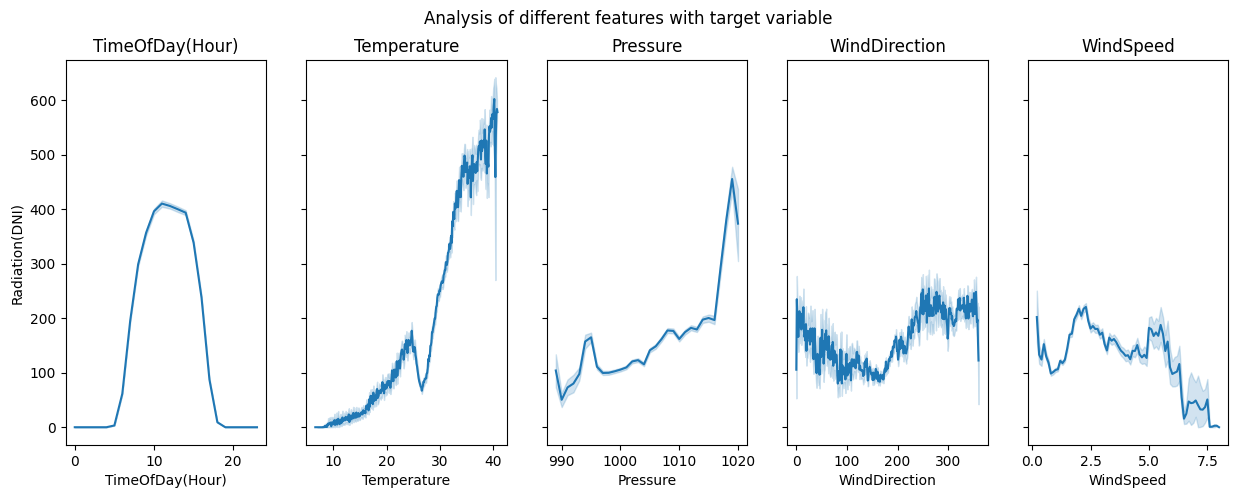

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), sharey=True)
fig.suptitle('Analysis of different features with target variable')

sns.lineplot(ax=axes[0], x=dataset['TimeOfDay(Hour)'].values, y=dataset['Radiation(DNI)'].values)
axes[0].set(xlabel='TimeOfDay(Hour)', ylabel = 'Radiation(DNI)')
axes[0].set_title(dataset['TimeOfDay(Hour)'].name)

sns.lineplot(ax=axes[1], x=dataset['Temperature'].values, y=dataset['Radiation(DNI)'].values)
axes[1].set(xlabel='Temperature', ylabel = 'Radiation(DNI)')
axes[1].set_title(dataset['Temperature'].name)

sns.lineplot(ax=axes[2],  x=dataset['Pressure'].values, y=dataset['Radiation(DNI)'].values)
axes[2].set(xlabel='Pressure', ylabel = 'Radiation(DNI)')
axes[2].set_title(dataset['Pressure'].name)

sns.lineplot(ax=axes[3],  x=dataset['WindDirection'].values, y=dataset['Radiation(DNI)'].values)
axes[3].set(xlabel='WindDirection', ylabel = 'Radiation(DNI)')
axes[3].set_title(dataset['WindDirection'].name)

sns.lineplot(ax=axes[4],  x=dataset['WindSpeed'].values, y=dataset['Radiation(DNI)'].values)
axes[4].set(xlabel='WindSpeed', ylabel = 'Radiation(DNI)')
axes[4].set_title(dataset['WindSpeed'].name)

### Pearson Correlation

In [ ]:
dataset.head()

,MonthOfYear,DayOfYear,TimeOfDay(Hour),TimeOfDay(Minute),Temperature,DewPoint,DiffuseHorizontalIrradiance(DHI),GlobalHorizontalIrradiance(GHI),SurfaceAlbedo,Pressure,WindDirection,WindSpeed,ClearskyDNI,CloudType,SolarZenithAngle,RelativeHumidity,Radiation(DNI)
0,1,1,0,0,16.9,13.6,0,0,0.12,1016,333,1.0,0,3,179.26,81.11,0
1,1,1,0,10,16.8,13.6,0,0,0.12,1016,336,1.0,0,3,177.94,81.63,0
2,1,1,0,20,16.7,13.6,0,0,0.12,1016,339,1.0,0,4,175.70,82.15,0
3,1,1,0,30,16.6,13.6,0,0,0.12,1016,343,1.0,0,7,173.43,82.67,0
4,1,1,0,40,16.5,13.7,0,0,0.12,1016,346,1.0,0,4,171.14,83.49,0


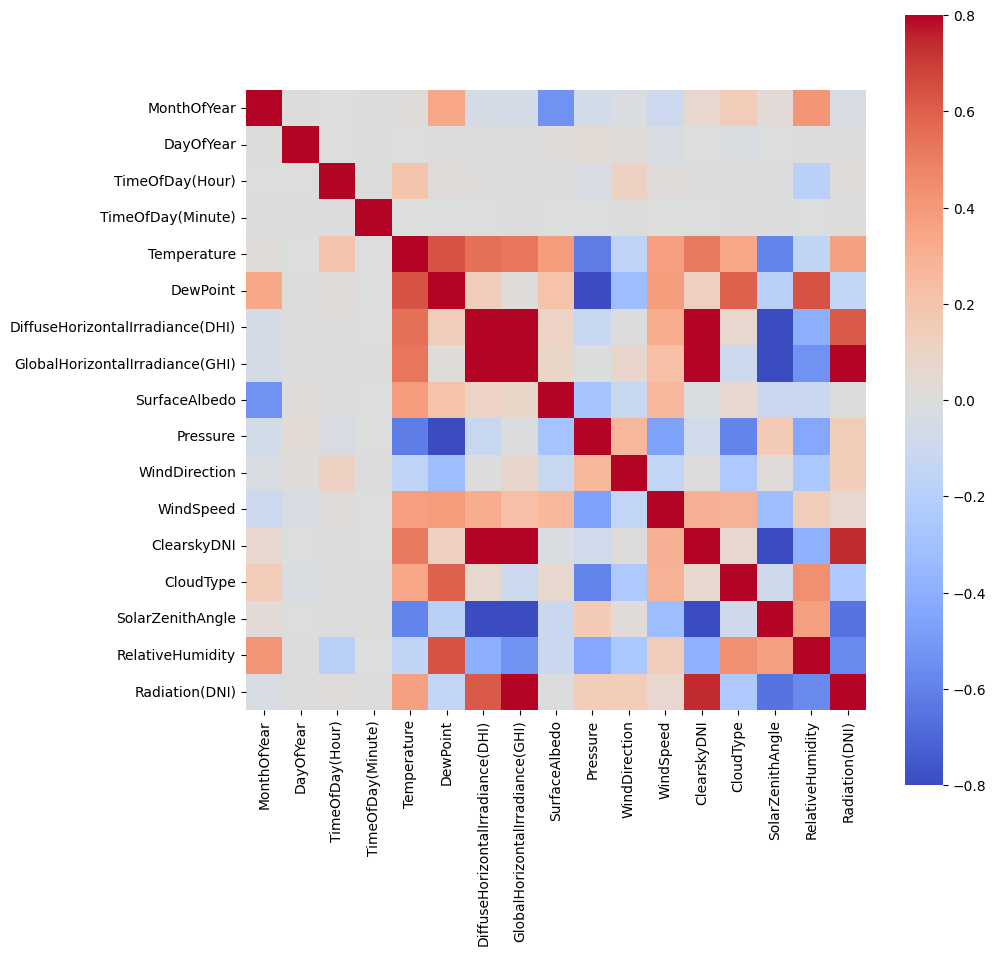

In [ ]:
# corrmat = dataset.drop(['MonthOfYear'], inplace=False, axis=1)
corrmat = dataset.corr()
f, ax = plt.subplots(figsize=(10,10))
sns.heatmap(corrmat, vmin=-.8, vmax=.8, square=True, cmap = 'coolwarm')
plt.show()

### Separating the Independent and Dependent Variables

In [ ]:
X = dataset[['MonthOfYear', 'DayOfYear', 'TimeOfDay(Hour)', 'TimeOfDay(Minute)',
            'Temperature', 'DewPoint', 'DiffuseHorizontalIrradiance(DHI)',
            'GlobalHorizontalIrradiance(GHI)', 'SurfaceAlbedo', 'Pressure',
            'WindDirection', 'WindSpeed', 'ClearskyDNI', 'CloudType',
            'SolarZenithAngle', 'RelativeHumidity']]
y = dataset['Radiation(DNI)']

## Multiple Linear Regression (MLR)

### Splitting the Dataset

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 150)

In [ ]:
#Fitting the Multiple Linear Regression model
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept: ", mlr.intercept_)
print("Coefficients:")
list(zip(dataset, mlr.coef_))

Intercept:  -737.7963585595804
Coefficients:


[('MonthOfYear', np.float64(-0.2804959762146861)),
 ('DayOfYear', np.float64(-0.127874051867666)),
 ('TimeOfDay(Hour)', np.float64(-0.15551549219851024)),
 ('TimeOfDay(Minute)', np.float64(-0.00028225930738562177)),
 ('Temperature', np.float64(-3.5510275534931734)),
 ('DewPoint', np.float64(4.56178749547351)),
 ('DiffuseHorizontalIrradiance(DHI)', np.float64(-1.507657977453535)),
 ('GlobalHorizontalIrradiance(GHI)', np.float64(1.1750056233631716)),
 ('SurfaceAlbedo', np.float64(-720.9111440342737)),
 ('Pressure', np.float64(1.021338496921606)),
 ('WindDirection', np.float64(0.04029812656576723)),
 ('WindSpeed', np.float64(-4.460644122750307)),
 ('ClearskyDNI', np.float64(0.16622841476380884)),
 ('CloudType', np.float64(-4.052572131062775)),
 ('SolarZenithAngle', np.float64(-0.40148161196100446)),
 ('RelativeHumidity', np.float64(-1.3518855223848942))]

In [ ]:
# Prediction of test set
y_pred_mlr = mlr.predict(X_test)

# Predicted values
print("Prediction for test set: {}".format(y_pred_mlr))

Prediction for test set: [  8.03518763 259.70577681  15.87987318 ... 268.95977482 475.03644089
 -20.83759969]


### Model Evaluation

In [ ]:
from sklearn import metrics
meanAbsoluteError = metrics.mean_absolute_error(y_test, y_pred_mlr)
meanSquaredError = metrics.mean_squared_error(y_test, y_pred_mlr)
rootMeanSquaredError = np.sqrt(metrics.mean_squared_error(y_test, y_pred_mlr))

print('R squared: {:.2f}'.format(mlr.score(X, y) *100))
print('Mean Absolute Error:', meanAbsoluteError)
print('Mean Square Error:', meanSquaredError)
print('Root Mean Square Error:', rootMeanSquaredError)

R squared: 92.45
Mean Absolute Error: 44.212494872363706
Mean Square Error: 3817.4138055808835
Root Mean Square Error: 61.78522319762941


## Random Forest Regressor

### Splitting the Dataset

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

### Feature Selection

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

regressor = RandomForestRegressor(n_estimators = 2)
regressor.fit(X_train, y_train)
feature_importances = regressor.feature_importances_

X_train_opt = X_train.copy()
removed_columns = pd.DataFrame()
models = []
r2s_opt = []

for i in range(0, 5):
    least_important = np.argmin(feature_importances)
    # Remove the least important feature and add it to removed_columns
    removed_feature = X_train_opt.pop(X_train_opt.columns[least_important])
    removed_columns = pd.concat([removed_columns, removed_feature], axis=1)

    regressor.fit(X_train_opt, y_train)
    feature_importances = regressor.feature_importances_
    accuracies = cross_val_score(estimator = regressor,
                                 X = X_train_opt,
                                 y = y_train, cv = 5,
                                 scoring = 'r2')
    r2s_opt = np.append(r2s_opt, accuracies.mean())
    models = np.append(models, ", ".join(list(X_train_opt)))

feature_selection = pd.DataFrame({'Features':models,'r2 Score':r2s_opt})
feature_selection.head()

,Features,r2 Score
0,"MonthOfYear, DayOfYear, TimeOfDay(Hour), TimeO...",0.999400
1,"MonthOfYear, DayOfYear, TimeOfDay(Hour), Tempe...",0.999372
2,"MonthOfYear, DayOfYear, Temperature, DewPoint,...",0.999421
3,"DayOfYear, Temperature, DewPoint, DiffuseHoriz...",0.999398
4,"Temperature, DewPoint, DiffuseHorizontalIrradi...",0.999407


### Fitting the Regressor to the Key Features

In [ ]:
X_train_best = X_train[['TimeOfDay(Hour)', 'Temperature', 'DiffuseHorizontalIrradiance(DHI)',
                        'GlobalHorizontalIrradiance(GHI)', 'Pressure',
                        'WindDirection', 'WindSpeed', 'ClearskyDNI']]
X_test_best = X_test[['TimeOfDay(Hour)', 'Temperature', 'DiffuseHorizontalIrradiance(DHI)',
                        'GlobalHorizontalIrradiance(GHI)', 'Pressure',
                        'WindDirection', 'WindSpeed', 'ClearskyDNI']]
regressor.fit(X_train_best, y_train)

RandomForestRegressor(n_estimators=2)

### Cross Validation

In [ ]:
accuracies = cross_val_score(estimator = regressor, X = X_train_best,y = y_train, cv = 10, scoring = 'r2')
accuracy = accuracies.mean()
print('r2 = {}'.format(accuracy))

r2 = 0.9982968124709801


### Predicting the Test Set

In [ ]:
from sklearn.metrics import explained_variance_score, mean_squared_error, r2_score

y_pred = regressor.predict(X_test_best)

explained_variance_score = explained_variance_score(y_test, y_pred)
mean_squared_error = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print('explained variance = {}'.format(explained_variance_score))
print('mse = {}'.format(mean_squared_error))
print('r2 = {}'.format(r_squared))

explained variance = 0.9982611600222505
mse = 87.83363832972883
r2 = 0.9982611552979545


### Visualising the Model

In [ ]:
# Predicting for whole dataset
dataset['y_pred'] = regressor.predict(dataset[['TimeOfDay(Hour)', 'Temperature', 'DiffuseHorizontalIrradiance(DHI)',
                        'GlobalHorizontalIrradiance(GHI)', 'Pressure',
                        'WindDirection', 'WindSpeed', 'ClearskyDNI']])

# Create Interactive Plot Using Bokeh
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import Range1d
output_notebook()

p = figure(title="Solar Irradiance Predictions",
           x_axis_label='Date and Time',
           y_axis_label='Solar Irradiance',
           x_axis_type="datetime",
           width=1000,  # Set width in pixels
           height=500)  # Set height in pixels

p.x_range = Range1d(dataset.index[0], dataset.index[600])
p.y_range = Range1d(-100, 1800, bounds=(-100, 1800))

p.line(dataset.index, dataset['Radiation(DNI)'], line_width=1)
p.line(dataset.index, dataset['y_pred'], line_width=1, line_color="red")

show(p, notebook_handle = True)

# Solar Irradiance Prediction with Neural Networks (MLP)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Assuming dataset is your DataFrame with the columns
X = dataset[['MonthOfYear', 'DayOfYear', 'TimeOfDay(Hour)', 'TimeOfDay(Minute)',
             'Temperature', 'DewPoint', 'DiffuseHorizontalIrradiance(DHI)',
             'GlobalHorizontalIrradiance(GHI)', 'SurfaceAlbedo', 'Pressure',
             'WindDirection', 'WindSpeed', 'ClearskyDNI', 'CloudType',
             'SolarZenithAngle', 'RelativeHumidity']]
y = dataset['Radiation(DNI)']

# 1. Preprocess the data
# Convert to numpy arrays
X = X.values
y = y.values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).view(-1, 1)  # Reshape to (n_samples, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

# 2. Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size=16):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),    # Input layer to first hidden layer
            nn.ReLU(),
            nn.Linear(64, 32),            # Second hidden layer
            nn.ReLU(),
            nn.Linear(32, 16),            # Third hidden layer
            nn.ReLU(),
            nn.Linear(16, 1)              # Output layer (1 value for regression)
        )

    def forward(self, x):
        return self.layers(x)

# 3. Initialize model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
model = MLP(input_size=16).to(device)
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

# Move data to GPU if available
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

# 4. Training loop
num_epochs = 200
batch_size = 32
n_samples = X_train.size(0)

for epoch in range(num_epochs):
    model.train()
    for i in range(0, n_samples, batch_size):
        batch_X = X_train[i:i+batch_size]
        batch_y = y_train[i:i+batch_size]

        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print loss every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# 5. Evaluate the model
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train)
    y_pred_test = model(X_test)

    train_loss = criterion(y_pred_train, y_train).item()
    test_loss = criterion(y_pred_test, y_test).item()

    print(f'Train MSE: {train_loss:.4f}')
    print(f'Test MSE: {test_loss:.4f}')

# Optional: Calculate R² score (for regression "accuracy")
from sklearn.metrics import r2_score
y_test_np = y_test.cpu().numpy()
y_pred_test_np = y_pred_test.cpu().numpy()
r2 = r2_score(y_test_np, y_pred_test_np)
print(f'Test R² Score: {r2:.4f}')

Epoch [20/200], Loss: 6.3441
Epoch [40/200], Loss: 11.4039
Epoch [60/200], Loss: 14.2628
Epoch [80/200], Loss: 18.4865
Epoch [100/200], Loss: 9.6231
Epoch [120/200], Loss: 10.6637
Epoch [140/200], Loss: 6.4505
Epoch [160/200], Loss: 4.8897
Epoch [180/200], Loss: 4.0382
Epoch [200/200], Loss: 3.1033
Train MSE: 2.1836
Test MSE: 2.5905
Test R² Score: 0.9999


In [ ]:
# Predict DNI for the new test dataset
new_test_dataset = pd.read_csv('/content/test_solar.csv')

feature_cols = ['MonthOfYear', 'DayOfYear', 'TimeOfDay(Hour)', 'TimeOfDay(Minute)',
                'Temperature', 'DewPoint', 'DiffuseHorizontalIrradiance(DHI)',
                'GlobalHorizontalIrradiance(GHI)', 'SurfaceAlbedo', 'Pressure',
                'WindDirection', 'WindSpeed', 'ClearskyDNI', 'CloudType',
                'SolarZenithAngle', 'RelativeHumidity']

X_new_test = new_test_dataset[feature_cols].values
X_new_test = scaler.transform(X_new_test)
X_new_test = torch.FloatTensor(X_new_test).to(device)

model.eval()
with torch.no_grad():
    y_pred_new_test = model(X_new_test)
    y_pred_new_test_np = y_pred_new_test.cpu().numpy()

# If predicted DNI is < 5, set it to 0
y_pred_new_test_np = np.where(y_pred_new_test_np < 5, 0, y_pred_new_test_np)

new_test_dataset['Predicted_Radiation(DNI)'] = y_pred_new_test_np.flatten()
output_filename = new_test_dataset.to_csv('/content/test_solar_predicted.csv', index=False)
print("New test dataset with predicted DNI saved as 'NewSolarIrradianceTest_Predicted.csv'")

print("First 5 rows of the new test dataset with predictions:")
print(new_test_dataset[['Radiation(DNI)', 'Predicted_Radiation(DNI)']].head())

New test dataset with predicted DNI saved as 'NewSolarIrradianceTest_Predicted.csv'
First 5 rows of the new test dataset with predictions:
   Radiation(DNI)  Predicted_Radiation(DNI)
0               0                       0.0
1               0                       0.0
2               0                       0.0
3               0                       0.0
4               0                       0.0


## MPPT TRACKING USING IRRIDIANCE

In [ ]:

dataset = pd.read_csv('/content/test_solar_predicted.csv', nrows=1000)

# *LONGi Hi-MO 5m LR5-72 HPH 540-560M Panel Specifications*
Vmp_min, Vmp_max = 38.6, 42
Imp_min, Imp_max = 10.4, 13.26
Voc_min, Voc_max = 46.5, 50
Isc_min, Isc_max = 11.2, 14
Pmax_min, Pmax_max = 404, 560
panel_efficiency = 0.21
panel_area = 1.5



PSO Algorithm

In [34]:

def Mppt_PSO(predicted_irradiance):
    """Particle Swarm Optimization (PSO) for Maximum Power Point Tracking (MPPT)"""

    # Handle zero irradiance case
    if predicted_irradiance == 0:
        return Vmp_min  # Safe default for zero irradiance
    num_particles = 20
    max_iters = 50
    c1, c2, w = 2.0, 2.0, 0.4

    # Estimate Power Output from Predicted Irradiance
    P_estimated = panel_efficiency * panel_area * predicted_irradiance

    # Estimate Nominal Voltage within Vmp range
    V_nominal = np.random.uniform(Vmp_min, Vmp_max) + 0.1 * predicted_irradiance
    I_estimated = np.clip(P_estimated / V_nominal, Imp_min, Imp_max)
    V_particles = np.random.uniform(Vmp_min, Vmp_max, num_particles)
    V_velocity = np.zeros(num_particles)

    # Initialize
    P_particles = np.minimum(V_particles * I_estimated, P_estimated)
    Pbest = np.copy(V_particles)
    Pbest_power = np.copy(P_particles)
    Gbest_idx = np.argmax(Pbest_power)
    Gbest = Pbest[Gbest_idx]
    Gbest_power = Pbest_power[Gbest_idx]

    # PSO Iteration Loop
    for _ in range(max_iters):
        for i in range(num_particles):
            V_current = V_particles[i]
            I_current = np.clip(P_estimated / V_current, Imp_min, Imp_max)
            P_current = np.minimum(V_current * I_current, P_estimated)
            if P_current > Pbest_power[i]:
                Pbest[i] = V_current
                Pbest_power[i] = P_current


            if P_current > Gbest_power:
                Gbest = V_current
                Gbest_power = P_current
            r1, r2 = np.random.rand(), np.random.rand()
            V_velocity[i] = (w * V_velocity[i] +
                             c1 * r1 * (Pbest[i] - V_particles[i]) +
                             c2 * r2 * (Gbest - V_particles[i]))

            V_particles[i] = np.clip(V_particles[i] + V_velocity[i], Vmp_min, Vmp_max)

    return np.clip(Gbest, Vmp_min, Vmp_max)

predicted_irradiance = dataset['Predicted_Radiation(DNI)']
print("\nPredicted Irradiance Values:", predicted_irradiance)

Vref_values = [Mppt_PSO(DNI) for DNI in predicted_irradiance]

print("\nPredicted MPPT Voltage Values:", Vref_values)




Predicted Irradiance Values: 0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
995    0.0
996    0.0
997    0.0
998    0.0
999    0.0
Name: Predicted_Radiation(DNI), Length: 1000, dtype: float64

Predicted MPPT Voltage Values: [38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, np.float64(40.94892463172846), np.float64(41.840847219736354), np.float64(40.17911121161808), np.float64(39.74245356637347), np.float64(39.3777083991414), np.float64(40.061488870152765), np.float64(41.093845769300756), np.float64(41.86295474332974), np.float64(39.506775310614465), np.float64(39.74408745894762), np.float64(40.58505912341262), np.float64(39.49643914914539), np.float64(41.103882805962634), np.float64(39.57413458677315), np.float64(38.622440290602775), np.float64(41.17868478569032), np.float


Dataset Display

In [35]:
output_df = pd.DataFrame({
    'Predicted Irradiance (DNI) [W/m²]': predicted_irradiance,
    'Optimal MPPT Voltage (Vref) [V]': Vref_values
})

print("\n *Solar Prediction & MPPT Voltage Table*")
print(output_df.to_string(index=False))  # Print table without index

#Save the Updated Results to a CSV File
output_filename = '/content/test_solar_predicted_with_mppt.csv'
output_df.to_csv(output_filename, index=False)
print(f"\nUpdated dataset saved as '{output_filename}'")



 *Solar Prediction & MPPT Voltage Table*
 Predicted Irradiance (DNI) [W/m²]  Optimal MPPT Voltage (Vref) [V]
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
                          0.000000                        38.600000
      

Visual Representation

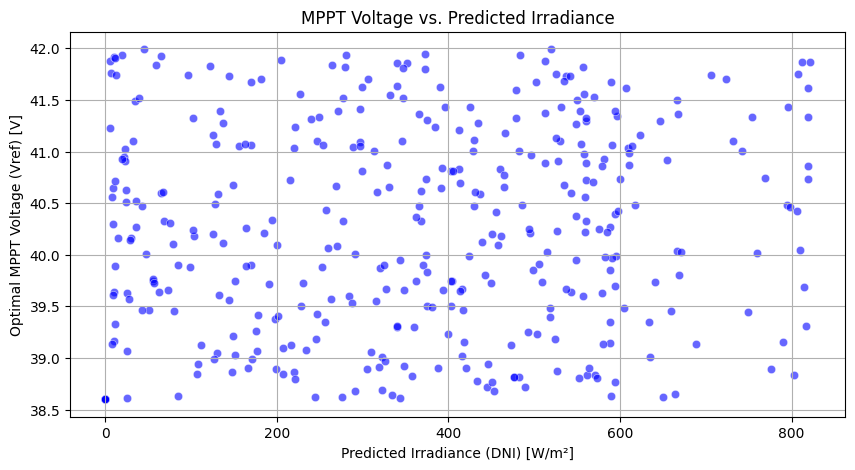

In [36]:

# *Plot the Results for Visualization*
plt.figure(figsize=(10, 5))
sns.scatterplot(x=output_df['Predicted Irradiance (DNI) [W/m²]'], y=output_df['Optimal MPPT Voltage (Vref) [V]'], color="blue", alpha=0.6)
plt.xlabel('Predicted Irradiance (DNI) [W/m²]')
plt.ylabel('Optimal MPPT Voltage (Vref) [V]')
plt.title('MPPT Voltage vs. Predicted Irradiance')
plt.grid(True)
plt.show()